## Previsão de Vendas em E-commerce com Machine Learning

##📌 Sobre o Projeto

Modelo de classificação para prever a ocorrência de pedidos em plataforma de e-commerce, desenvolvido para otimizar o planejamento logístico.

##🎯 Objetivo
Estimar se haverá **pelo menos uma ordem de compra** para cada cliente em uma data específica, possibilitando melhor alocação de recursos logísticos.

##📊 Dataset

- `account_id`: ID do cliente
- `order_date`: Data da transação  
- `total_amount`: Valor total (R$)
- `total_orders`: Quantidade de pedidos

*Dataset: Histórico de transações de julho/2022*

## Importação de Bibliotecas

In [11]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr


## Carregamento e Análise Exploratória

In [12]:
upload = files.upload()
historical_orders = pd.read_csv('historical_orders.csv')

Saving historical_orders.csv to historical_orders (1).csv


In [13]:
# Explorando os dados
historical_orders.head()
historical_orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980003 entries, 0 to 980002
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   account_id    980003 non-null  object 
 1   order_date    980003 non-null  object 
 2   total_amount  980003 non-null  float64
 3   total_orders  980003 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 29.9+ MB


In [14]:
#Conversão das datas
historical_orders['order_date'] = pd.to_datetime(historical_orders['order_date'])

In [15]:
def criar_resumo (df):

  resumo = {}

  #Dados Faltantes
  resumo['dados_faltantes'] = df.isnull().sum()

  #Número de clientes únicos
  resumo['num_account_id_unique'] =  df['account_id'].nunique()

  #Menor e maior datas
  resumo['max_date'] = df['order_date'].max()
  resumo['min_date'] = df['order_date'].min()

  #Estatísticas de Transação (total_amount)
  resumo['max_amount'] = df['total_amount'].max()
  resumo['min_amount'] = df['total_amount'].min()
  resumo['median_amount'] = df['total_amount'].median()
  resumo['mean_amount'] = df['total_amount'].mean()
  resumo['sum_amount'] = df['total_amount'].sum()

  #Top 3 clientes (total_amount)
  top3_clients = (df.groupby('account_id')['total_amount']
                  .sum()
                  .sort_values(ascending=False)
                  .head(3))

  resumo['top3_clients'] = top3_clients.index.tolist()


  #Estísticas de Order (total_orders)
  #Avaliar o mínimo e máximo de ordem para cada cliente em um dia.
  daily_orders = df.groupby(['account_id','order_date'])['total_orders'].sum()
  resumo['min_orders_day'] = daily_orders.min()
  resumo['max_orders_day'] = daily_orders.max()


  return resumo

In [16]:
resumo = criar_resumo(historical_orders)
print(resumo)

{'dados_faltantes': account_id      0
order_date      0
total_amount    0
total_orders    0
dtype: int64, 'num_account_id_unique': 31613, 'max_date': Timestamp('2022-07-31 00:00:00'), 'min_date': Timestamp('2022-07-01 00:00:00'), 'max_amount': 1008409.1100000005, 'min_amount': 0.0, 'median_amount': 0.0, 'mean_amount': np.float64(180.3886725142678), 'sum_amount': np.float64(176781440.23), 'top3_clients': ['BR_27873143000164', 'BR_35796707787', 'BR_30179280000108'], 'min_orders_day': 0, 'max_orders_day': 154}


In [17]:
# Colunas em historical_orders com informações complementares

historical_orders = (historical_orders.assign(
    day_of_week = historical_orders['order_date'].dt.dayofweek,
    day_of_year = historical_orders['order_date'].dt.dayofyear,
    day = historical_orders['order_date'].dt.day,
    weekend = np.where(historical_orders['order_date']
                       .dt.dayofweek.isin([5,6]), 1,0),
    order = (historical_orders['total_orders'] > 0).astype(int)

))

In [18]:
# DataFrame agrupado por DIA DO ANO  (total_orders/total_amount)

historical_orders_grouped = (historical_orders
                             .groupby('day_of_year')[['total_orders', 'total_amount']]
                             .sum()
                             .reset_index()
                             .sort_values('day_of_year')
                             .reset_index(drop=True))

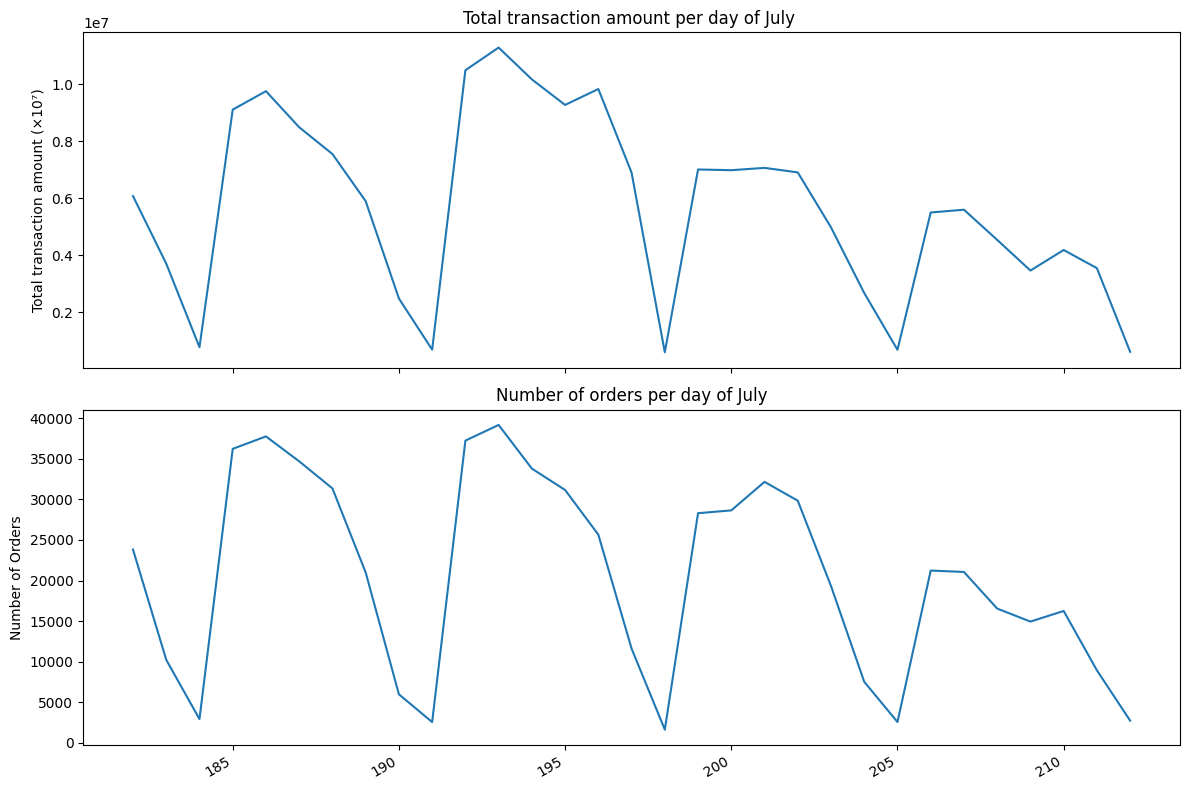

In [19]:

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,8), sharex=True)

# Total de transações por dia (total_amount)
ax1.plot(historical_orders_grouped['day_of_year'],
         historical_orders_grouped['total_amount'])
ax1.set_ylabel('Total transaction amount (×10⁷)')
ax1.set_title('Total transaction amount per day of July ')

#Total de transações por dia (total_orders)
ax2.plot(historical_orders_grouped['day_of_year'],
         historical_orders_grouped['total_orders'])
ax2.set_ylabel('Number of Orders')
ax2.set_title('Number of orders per day of July')

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## Feature Engineering

In [20]:
#Escolhendo um ID para analisar o comportamento de compra.

#ID Aleatório: BR_35796707787

def plot_user(account_id: str, df: pd.DataFrame) -> None:

  #Verificar se o usuário é válido
  if account_id not in df['account_id'].unique():
    print(f"User {account_id} unknown")
    return

  #Filtrando apenas resultados do cliente
  df_user = df[df['account_id'] == account_id]

  #Preparando os valores
  df_user_grouped = (df_user.groupby('day_of_year')[['total_amount','total_orders']]
                    .sum().reset_index()
                    .sort_values('day_of_year').reset_index(drop=True))

  #Plotando os gráficos

  #GRÁFICO DE SÉRIE

  fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True, constrained_layout=True)

  #Transações por dia (total_amount)
  ax1.plot(df_user_grouped['day_of_year'], df_user_grouped['total_amount'])
  ax1.set_ylabel('Total transaction amount')
  ax1.set_title(f'Total transaction amount per day of July')

  #Transações por dia (total_orders)
  ax2.plot(df_user_grouped['day_of_year'], df_user_grouped['total_orders'])
  ax2.set_ylabel('Number of Orders')
  ax2.set_title('Number of Orders per day of July')

  fig.autofmt_xdate()
  fig.tight_layout()
  plt.show()


  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharex=True, constrained_layout=True)

  # Análise de dias da semana com mais ordens
  # Finalidade de verificar quais dias da semana tem mais ordem

  df_week = (df_user[df_user['order'] == 1]
             .groupby('day_of_week')['order']
             .sum()
             .reset_index(name='num_orders'))

  #Gráfico histograma
  ax1.bar(df_week['day_of_week'], df_week['num_orders'], color='darkblue')
  ax1.set_xlabel('Day of week (0=Monday, 6=Sunday)')
  ax1.set_ylabel('Number of orders')
  ax1.set_title('Number of orders per day of Week')


  #Análise de Ticket Médio
  #Finalidade de verificar se os dias com mais pedido também são de maior valor
  df_ticket_week = (
      df_user[df_user['total_orders'] > 0]
      .groupby('day_of_week')[['total_amount', 'total_orders']]
      .sum()
      .assign(ticket_medio=lambda x: x['total_amount'] / x['total_orders'])
      .reset_index()
  )

  #Gráfico histograma
  ax2.bar(df_ticket_week['day_of_week'], df_ticket_week['ticket_medio'],color='darkorange')
  ax2.set_xlabel('Day of week (0=Monday, 6=Sunday)')
  ax2.set_ylabel('Ticket médio')
  ax2.set_title('Ticket médio per day of Week')

  plt.tight_layout()
  plt.show()


/tmp/ipython-input-1503888289.py:37: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


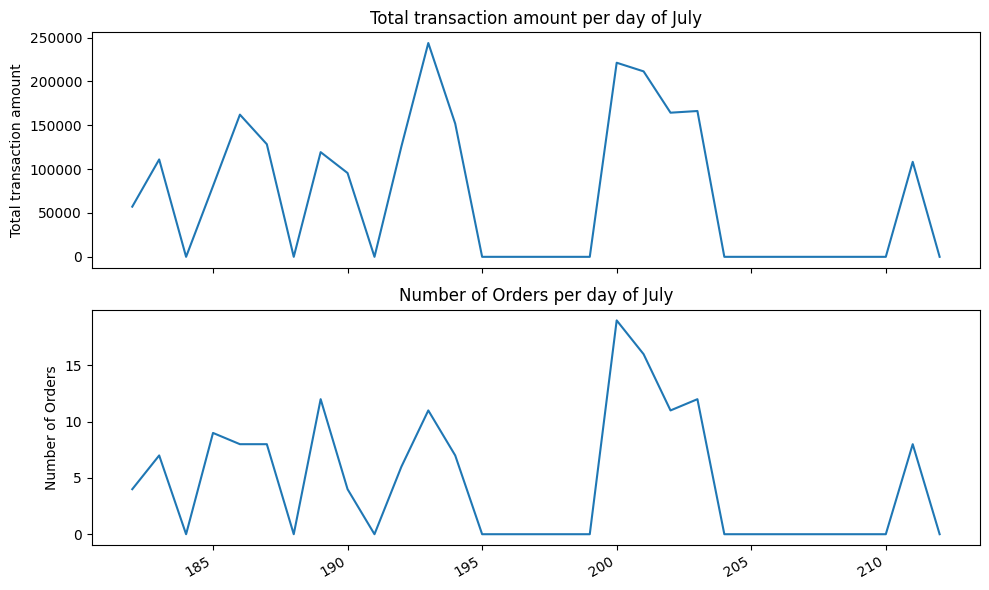

/tmp/ipython-input-1503888289.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


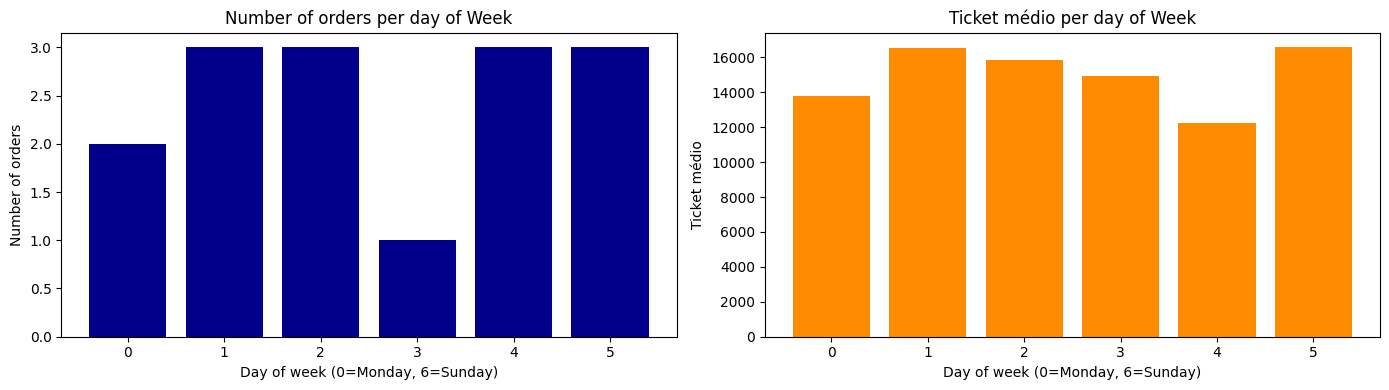

None


In [21]:
user_data = plot_user('BR_35796707787', historical_orders)
print(user_data)


**GRÁFICO DE LINHA**

Observando os gráficos de valor transacionado e número de pedidos ao longo do mês de julho, nota-se que, no início do mês, o cliente realiza compras esporádicas, com valores e quantidades de pedidos relativamente moderados.

No meio do mês, há a ocorrência de dois picos expressivos, tanto em volume financeiro quanto em número de pedidos, indicando períodos de maior intensidade na atividade de compras. Esses picos, por sua vez, são seguidos por uma queda abrupta, com vários dias consecutivos sem registros, o que reforça um comportamento de consumo concentrado em períodos específicos do mês.

Ao final do gráfico, observa-se uma retomada das transações, porém em menor intensidade quando comparada aos picos centrais.

De forma geral, o cliente aparenta concentrar suas compras em momentos específicos do mês, intercalados por dias de inatividade e seguidos por transações moderadas, possivelmente associadas à reposição de estoque ou a eventos pontuais.


**HISTOGRAMA 01 - Numbers of orders per Week**

Observando o gráfico, nota-se que os dias de maior frequência de pedidos são terça, quarta, sexta e sábado. A segunda-feira apresenta uma frequência moderada, enquanto a quinta-feira possui baixa ocorrência de pedidos. Não há registros de compras aos domingos, o que define bem o ciclo de inatividade semanal do cliente.

**HISTOGRAMA 02 - Ticket Médio**

Ao analisar o ticket médio, nota-se que a quantidade de ordens não apresenta uma correlação direta com o volume gasto. Embora alguns dias tenham mais pedidos, o valor médio das transações permanece equilibrado ao longo da semana, com a segunda-feira e a sexta-feira apresentando valores levemente inferiores. Isso sugere que, independentemente da frequência, o perfil de gasto por pedido é constante.

**SEGMENTAÇÃO DE CLIENTES**

Esta etapa tem a finalidade de agrupar clientes com padrões semelhantes de compra ao longo da semana. Essa segmentação é fundamental para que o modelo identifique comportamentos específicos e rotinas de consumo.

In [22]:
def compute_day_odds(group):
    odds = {}
    # Ordem das datas 0 = Mon, 6 = Sun
    day_names = ["mon", "tue", "wed", "thurs", "fri", "sat", "sun"]

    for i, name in enumerate(day_names):
        mask = group['day_of_week'] == i
        odds[f'odds_{name}'] = (
            group.loc[mask, 'order'].mean() if mask.sum() > 0 else 0.0
        )
    return pd.Series(odds)

account_id_odds = (historical_orders.groupby('account_id')
                   .apply(compute_day_odds)
                   .reset_index())

/tmp/ipython-input-2592077066.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_day_odds)


In [23]:
odds_cols = ['odds_mon', 'odds_tue', 'odds_wed', 'odds_thurs', 'odds_fri']
weekend_cols = ['odds_sat', 'odds_sun']

account_id_odds['mean_weekday'] = account_id_odds[odds_cols].mean(axis=1)
account_id_odds['mean_weekend'] = account_id_odds[weekend_cols].mean(axis=1)
account_id_odds['active_days'] = (account_id_odds[odds_cols + weekend_cols] > 0).sum(axis=1)



In [24]:
def segment_client(row):
    if row['mean_weekday'] > 0.3 and row['mean_weekend'] < 0.1:
        return 'Weekday Buyer'
    elif row['mean_weekend'] > row['mean_weekday']:
        return 'Weekend Buyer'
    elif row['active_days'] >= 5:
        return 'High Frequency'
    else:
        return 'Low Activity'

account_id_odds['segment'] = account_id_odds.apply(segment_client, axis=1)


In [25]:
account_id_odds.head()

,account_id,odds_mon,odds_tue,odds_wed,odds_thurs,odds_fri,odds_sat,odds_sun,mean_weekday,mean_weekend,active_days,segment
0,BR_00000343803,0.0,0.00,0.75,0.0,0.0,0.2,0.0,0.15,0.1,2,Low Activity
1,BR_00001415930,0.0,0.00,0.00,0.0,0.8,0.0,0.0,0.16,0.0,1,Low Activity
2,BR_00001760106,0.0,0.25,0.50,0.0,0.0,0.2,0.0,0.15,0.1,3,Low Activity
3,BR_00002485176,0.0,0.00,0.00,0.0,0.0,0.2,0.0,0.00,0.1,1,Weekend Buyer
4,BR_00002536340,0.0,0.75,0.00,0.0,0.0,0.0,0.0,0.15,0.0,1,Low Activity


Nesta etapa, aplicou-se uma segmentação baseada em regras (rule-based) para mapear a regularidade de cada cliente, priorizando a frequência das compras em detrimento do volume financeiro. Foi utilizada a tabela account_id_odds para calcular a probabilidade média de pedidos em cada dia da semana para cada ID específico.

Essa abordagem permite identificar perfis comportamentais distintos, diferenciando clientes que compram grandes volumes de forma esporádica daqueles que mantêm uma operação constante.

Ao integrar estas probabilidades como variáveis (features) nos modelos de Machine Learning, o algoritmo passa a dispor de um histórico do comportamento individual de cada conta. Assim, a predição deixa de depender apenas de datas gerais e passa a considerar o hábito de consumo de cada cliente, tornando a estimativa logística mais precisa.

In [26]:
account_id_odds[account_id_odds['account_id'] == 'BR_35796707787']


,account_id,odds_mon,odds_tue,odds_wed,odds_thurs,odds_fri,odds_sat,odds_sun,mean_weekday,mean_weekend,active_days,segment
20052,BR_35796707787,0.5,0.75,0.75,0.25,0.6,0.6,0.0,0.57,0.3,6,High Frequency


Análise do Cliente (ID: BR_35796707787) Ao cruzar a análise visual (gráficos de série e histogramas) com a segmentação por regras, observa-se uma convergência dos dados:

*Perfil de Compra:* O cliente foi classificado como High Frequency, apresentando atividade em 6 dos 7 dias da semana.

*Consistência vs. Volume:* Embora os picos de volume financeiro ocorram no meio da semana (especialmente terças e quartas), a tabela de odds revela que o cliente mantém uma presença consistente de segunda a sábado.

*Validação:* O domingo foi evidenciado com odds de 0.0, confirmando a ausência de transações observada nos gráficos. Em contrapartida, o sábado apresenta uma probabilidade de 0.6, o que reflete a retomada de pedidos identificada na série temporal de julho.

A combinação da visualização de dados com a segmentação permitiu entender que este cliente possui um perfil de alta frequência, com comportamento distribuído ao longo da semana e concentrado em dias úteis e sábados. Esse é um perfil estratégico para ações de fidelização e logística programada.

## Modelagem


**TREINANDO MODELOS PREDITIVOS**

Nesta etapa, a variável alvo (target) utilizada foi a order, que indica a ocorrência ou não de pedidos em um determinado dia.
Como variáveis explicativas (features), foram utilizadas informações temporais (dia da semana e dia do mês) e variáveis comportamentais derivadas da segmentação dos clientes (probabilidades médias de atividade por dia). Essa escolha permite ao modelo compreender tanto os padrões sazonais do mercado quanto o comportamento individual de compra.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [28]:
# Merge historical orders e account id odds
historical_orders = pd.merge(historical_orders, account_id_odds, on='account_id', how='left')

historical_orders['month'] = historical_orders['order_date'].dt.month
odds_cols = [f'odds_{day}' for day in ["mon", "tue", "wed", "thurs", "fri", "sat", "sun"]]
historical_orders[odds_cols] = historical_orders[odds_cols].fillna(0)

# Target
historical_orders['order'] = (historical_orders['total_orders'] > 0).astype(int)

# DEFINIÇÃO DE FEATURES (X) E TARGET (y)
cols_to_drop = ['order', 'account_id', 'order_date', 'total_amount', 'total_orders']
existing_drops = [c for c in ['segment', 'week', 'day_of_year', 'mean_weekday', 'mean_weekend', 'active_days'] if c in historical_orders.columns]

X = historical_orders.drop(columns=cols_to_drop + existing_drops)
y = historical_orders['order']

# Definindo variáveis para o preprocessor
numeric_features = ['day', 'day_of_week', 'month'] + odds_cols
categorical_features = ['weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# SPLIT CRONOLÓGICO
# O modelo só capta dados do passado durante o treino, simulando a realidade
historical_orders_sorted = historical_orders.sort_values('order_date')
cutoff_date = pd.Timestamp('2022-07-24')

train_mask = historical_orders_sorted['order_date'] <= cutoff_date
test_mask = historical_orders_sorted['order_date'] > cutoff_date

X_train = historical_orders_sorted.drop(columns=cols_to_drop + existing_drops)[train_mask]
X_test = historical_orders_sorted.drop(columns=cols_to_drop + existing_drops)[test_mask]
y_train = historical_orders_sorted['order'][train_mask]
y_test = historical_orders_sorted['order'][test_mask]

print(f"Treino: até {cutoff_date.date()} → {len(X_train)} amostras")
print(f"Teste:  após {cutoff_date.date()} → {len(X_test)} amostras")
print(f"Proporção teste: {len(X_test)/(len(X_train)+len(X_test)):.1%}")

# FUNÇÃO DE AVALIAÇÃO (com suporte a threshold customizado)
def evaluate_models(models_dict, X_train, X_test, y_train, y_test, threshold=0.5):
    results = {}
    for name, model in models_dict.items():
        # Pipeline
        pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
        pipe.fit(X_train, y_train)

        y_proba = pipe.predict_proba(X_test)[:, 1]
        # Aplica o threshold definido ao invés de usar o padrão (0.5)
        y_pred = (y_proba >= threshold).astype(int)

        # Estatísticas para avaliar a performance
        results[name] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, zero_division=0),
            'AUC-ROC': roc_auc_score(y_test, y_proba)
        }

    summary_df = pd.DataFrame(results).T.round(3)
    print(f"\nSummary Metrics (threshold={threshold}):\n", summary_df)
    return results, summary_df

# DECLARAÇÃO DOS MODELOS
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

# Threshold 0.3: priorizando Recall para minimizar Falsos Negativos
# No contexto logístico, é mais custoso não atender um pedido real
# do que se preparar para um pedido que não acontece
results, summary = evaluate_models(models, X_train, X_test, y_train, y_test, threshold=0.3)

Treino: até 2022-07-24 → 758712 amostras
Teste:  após 2022-07-24 → 221291 amostras
Proporção teste: 22.6%

Summary Metrics (threshold=0.3):
                      Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.327      0.094   0.931     0.171    0.745
Random Forest           0.836      0.289   0.823     0.428    0.893


O modelo preditivo tem como finalidade prever a ocorrência de ao menos uma ordem de compra para cada cliente em uma data específica. Para a execução, foram utilizados os algoritmos de **Regressão Logística e Random Forest**, por serem modelos robustos para problemas de classificação binária.

O maior desafio encontrado foi o desbalanceamento significativo dos dados. Como a maioria dos dias não apresentava vendas, os modelos tendiam inicialmente a ignorar as ocorrências de compra. Como solução, foi aplicada a técnica de pesos balanceados (class_weight='balanced'), e o threshold de decisão foi ajustado para 0.3, priorizando o Recall,isto é, a capacidade de detectar vendas que realmente aconteceram. Essa escolha foi guiada pela lógica do negócio: no contexto logístico, o custo de não atender um pedido real é maior do que se preparar para um pedido que não acontece.

Os dados foram divididos de forma cronológica, com o modelo treinando até o dia 24 de julho e sendo testado nos dias seguintes. Isso simula melhor a realidade, pois o modelo só utiliza informações do passado para fazer suas previsões. A limitação temporal da base (dados restritos a julho de 2022) impediu o modelo de compreender padrões sazonais mais longos, como feriados ou sazonalidades mensais. Dessa forma, embora o modelo atual seja eficaz em sinalizar padrões semanais, sua precisão pode ser otimizada com a inclusão de um histórico de dados mais extenso.

## Avaliação de Resultados

<Figure size 800x600 with 0 Axes>

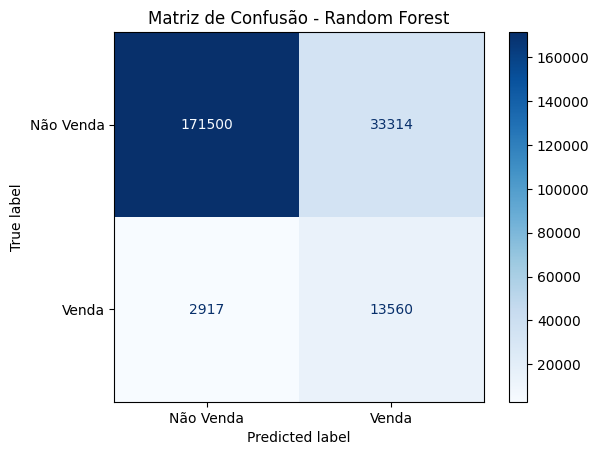

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Visualização do Random Forest
model_rf = Pipeline([('preprocessor', preprocessor),
                     ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))])
model_rf.fit(X_train, y_train)

y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.3).astype(int)

# Matriz
cm = confusion_matrix(y_test, y_pred_rf)

# Gráfico
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Venda', 'Venda'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

A Matriz de Confusão foi implementada para diagnosticar os erros do modelo (Falsos Positivos x Falsos Negativos). Em um contexto de planejamento logístico, a análise reflete uma decisão estratégica importante: a priorização da continuidade operacional. Dessa forma, esse modelo prioriza a minimização de Falsos Negativos, dado que, no setor logístico, o custo de oportunidade de não atender um pedido confirmado é superior ao custo operacional de um Falso Positivo (preparação preventiva).

*Recall (Sensibilidade):* Com a aplicação da técnica de pesos balanceados (class_weight='balanced') e o ajuste do threshold para 0.3, o modelo atingiu um Recall de 0.823. Isso demonstra que o sistema é capaz de capturar 82,3% de todas as oportunidades de venda reais, garantindo prontidão no atendimento à demanda. Essa escolha resultou em um número maior de Falsos Positivos (33.314), ou seja, dias preparados sem que houvesse venda. No entanto, trata-se de um tradeoff consciente: o modelo foi configurado para não perder vendas reais, priorizando a continuidade operacional.

*AUC-ROC (Capacidade de Distinção):* O índice AUC-ROC de 0.893 confirma a boa capacidade discriminatória do modelo, indicando que ele consegue separar bem os dias com venda dos dias sem venda.

/tmp/ipython-input-4161931872.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importance_df, palette='magma')


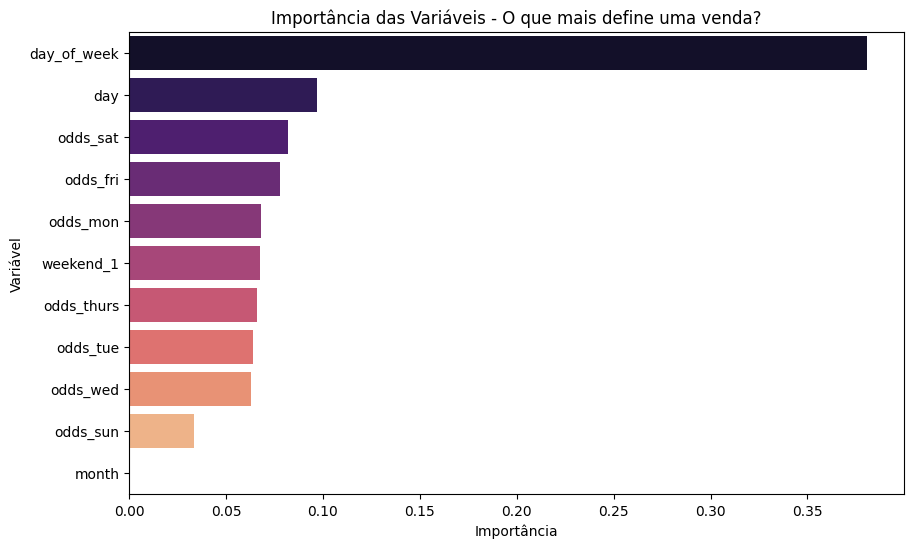

In [30]:
feature_names = numeric_features + list(model_rf.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features))
importances = model_rf.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'Variável': feature_names, 'Importância': importances}).sort_values(by='Importância', ascending=False)

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importance_df, palette='magma')
plt.title('Importância das Variáveis - O que mais define uma venda?')
plt.show()

*Sazonalidade Semanal (day_of_week)*: Esta variável lidera a importância, evidenciando que o negócio é fortemente regido por uma rotina semanal. O modelo identificou que o dia da semana é o sinal mais forte para prever uma venda, refletindo o comportamento da maioria dos clientes que concentram seus pedidos em dias úteis.

*Ciclo Mensal (day):* A alta relevância do dia do mês indica que o comportamento de compra oscila conforme o calendário (início, meio e fim do mês), possivelmente ligado a ciclos de pagamento e fechamento de metas. Para o algoritmo, esse padrão mensal é um preditor mais estável do que o comportamento isolado de certos clientes.

*Hábito Individual (odds_sat e odds_fri):* A presença destas variáveis no topo mostra que o comportamento de sexta e sábado é o que mais varia entre os clientes. Enquanto os dias úteis seguem um padrão geral, o modelo utiliza as "odds" customizadas para identificar quais clientes específicos têm o hábito de comprar nos finais de semana.


## 📚  Considerações Finais

Este projeto foi desenvolvido como trabalho final do curso **Introdução à Ciência de Dados e Métodos Quantitativos** (USP - 2026).

O desenvolvimento incluiu auxílio de LLMs para:
- Refinamento técnico da documentação
- Validação de pipeline e prevenção de data leakage
- Orientação em técnicas de modelagem

Todo o código foi revisado, testado e compreendido integralmente.

---

**Desenvolvido por:** Maria Gabriela Martins de Souza  
**LinkedIn:** [linkedin.com/in/mgabrielamnts](https://linkedin.com/in/mgabrielamnts)  
**GitHub:** [github.com/mgabrielamnts](https://github.com/mgabrielamnts)